# Pitch & Putt Shot Classifier v1

## Goal
Build a classifier that can identify **pitch**, **chip**, and **putt** shots from wrist accelerometer data recorded on a Garmin FR 255.

## Data
Three rounds of labelled data:
- **Round 1** (Apr 9): 18 holes, 50 shots — labelled by alignment (medium confidence)
- **Round 2** (Apr 11): 10 holes, 34 shots — **recorded with long sleeve over watch** (dampened signal, excluded from training)
- **Round 3** (Apr 13): 18 holes, 54 shots — labelled with shot marker button + window correction (high confidence)

## Features
The watch app records 8 features per second:
- `peak_mag`: highest accelerometer magnitude (mg) in that second
- `min_mag`: lowest magnitude
- `mean_mag`: average magnitude
- `std_mag`: standard deviation of magnitude (how much variation within the second)
- `max_jerk`: largest change in magnitude between consecutive samples (rate of change)
- `peak_x`, `peak_y`, `peak_z`: highest absolute value on each axis

## Approach
1. Load and combine labelled data from R1 and R3
2. Explore the feature space
3. Train several classifiers and compare them
4. Evaluate with cross-validation
5. Analyse what works and what doesn't

## Future improvement
GPS course mapping could eliminate the chip-vs-putt problem entirely: any shot taken on the green = putt.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.pipeline import Pipeline

pd.set_option('display.max_columns', 30)
pd.set_option('display.width', 200)
np.random.seed(42)

---
## 1. Load and combine data

We use R1 + R3 (both bare wrist). R2 (sleeve) is excluded from training but we'll test on it later to see how the classifier handles different conditions.

In [2]:
r1 = pd.read_csv('round1_labelled_shots.csv')
r3 = pd.read_csv('round3_labelled_shots.csv')

# R1: keep only real shots (remove false positives from threshold-based detection)
r1 = r1[r1['label'].isin(['pitch', 'chip', 'putt'])].copy()
r1['round'] = 'R1'
r1['confidence'] = r1.get('confidence', 'medium')

# R3: high confidence, window-corrected
r3['round'] = 'R3'
r3['confidence'] = 'high'

# Combine
feat_cols = ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']
combined = pd.concat([r1[feat_cols + ['label', 'round']], r3[feat_cols + ['label', 'round']]], ignore_index=True)

print(f'Total samples: {len(combined)}')
print(f'\nPer class:')
print(combined['label'].value_counts())
print(f'\nPer round:')
print(combined.groupby(['round', 'label']).size().unstack(fill_value=0))

Total samples: 94

Per class:
label
putt     47
pitch    36
chip     11
Name: count, dtype: int64

Per round:
label  chip  pitch  putt
round                   
R1        6     18    16
R3        5     18    31


---
## 2. Exploratory Data Analysis (EDA)

Before training any model, we need to **understand the data**. The most important questions:
1. Can we see the 3 classes visually in the feature space?
2. Which features separate the classes best?
3. Are there any issues (outliers, class imbalance, overlapping distributions)?

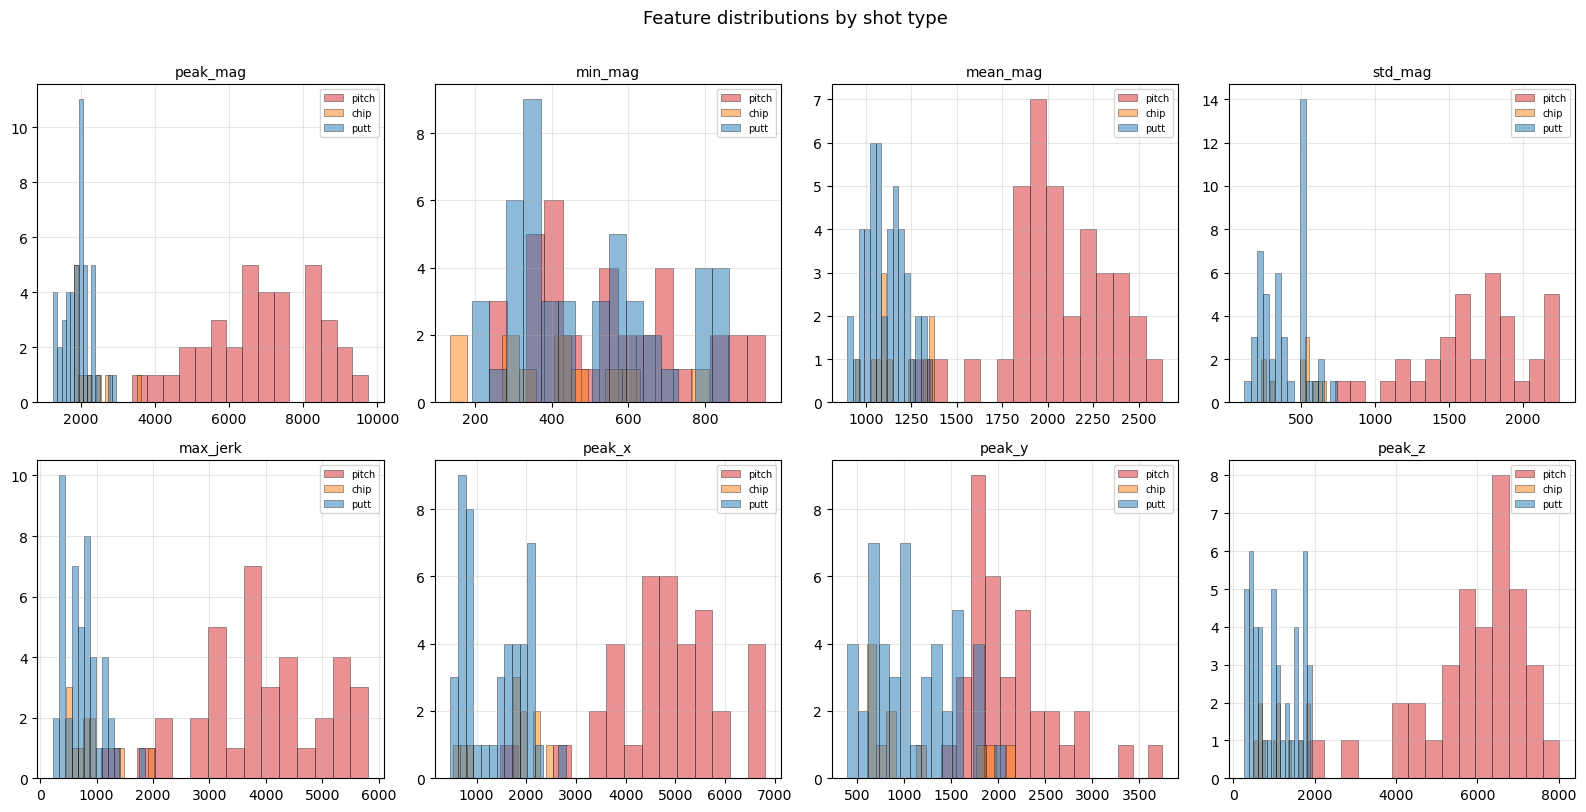

In [3]:
# 2a. Distribution of each feature by class
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
colors = {'pitch': 'C3', 'chip': 'C1', 'putt': 'C0'}

for ax, feat in zip(axes.flat, feat_cols):
    for label in ['pitch', 'chip', 'putt']:
        vals = combined[combined['label'] == label][feat]
        ax.hist(vals, bins=15, alpha=0.5, label=label, color=colors[label], edgecolor='black', linewidth=0.5)
    ax.set_title(feat, fontsize=10)
    ax.legend(fontsize=7)
    ax.grid(alpha=0.3)

plt.suptitle('Feature distributions by shot type', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

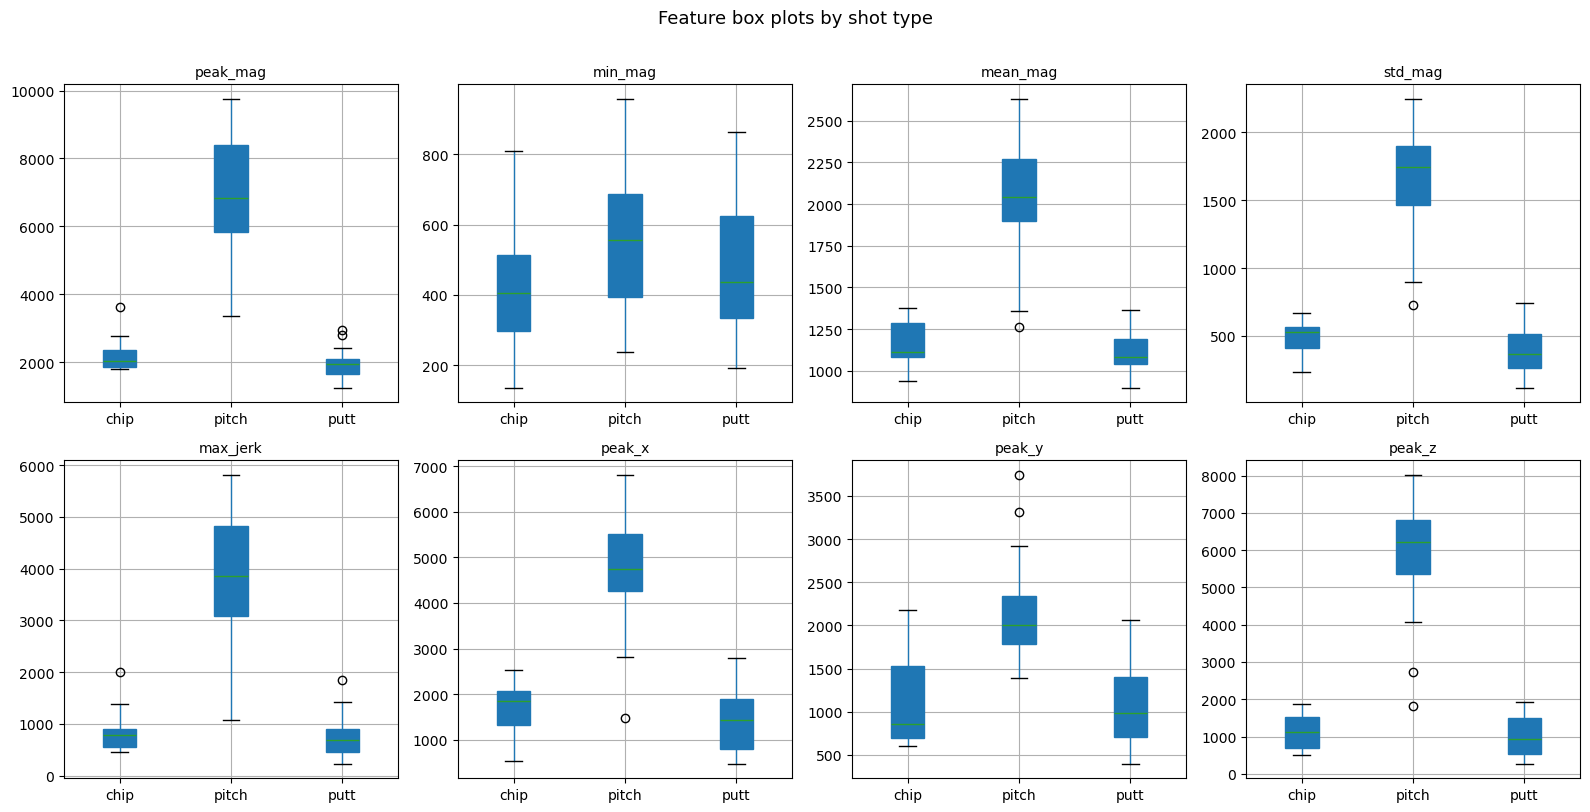

In [4]:
# 2b. Box plots — easier to compare medians and spread
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, feat in zip(axes.flat, feat_cols):
    combined.boxplot(column=feat, by='label', ax=ax,
                     positions=[0, 1, 2],  # fixed positions for chip, pitch, putt
                     patch_artist=True)
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('')

plt.suptitle('Feature box plots by shot type', fontsize=13, y=1.01)
plt.tight_layout()
plt.show()

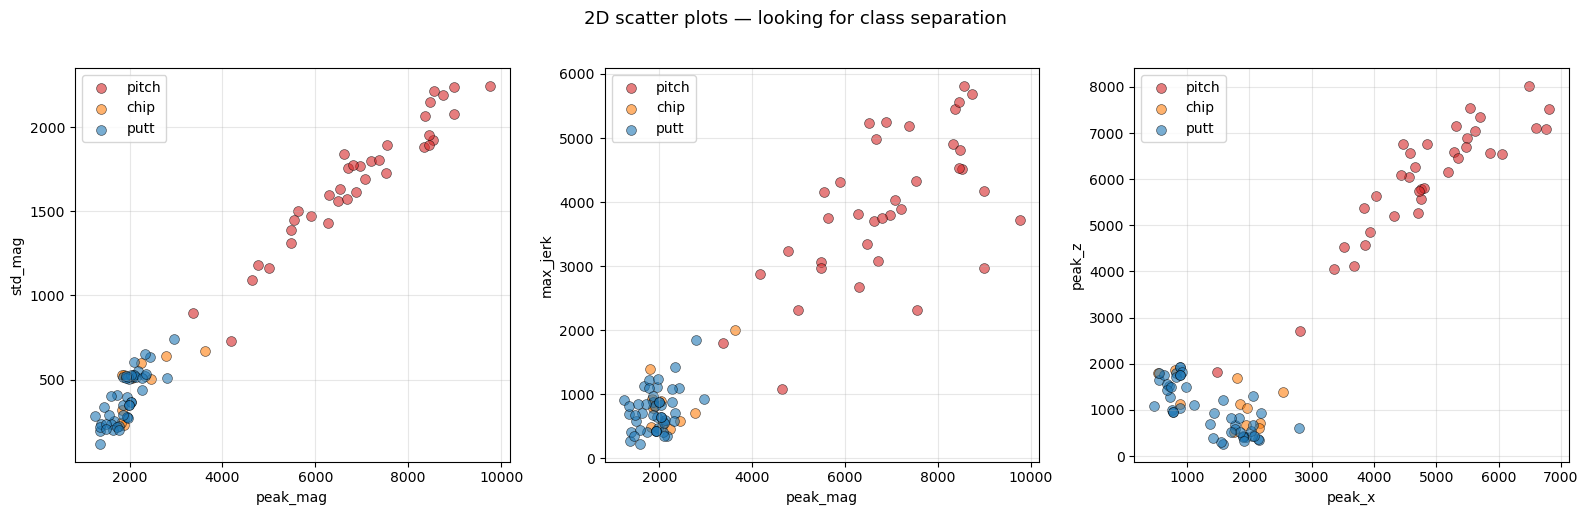

In [5]:
# 2c. Scatter plots of the most promising feature pairs
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('peak_mag', 'std_mag'), ('peak_mag', 'max_jerk'), ('peak_x', 'peak_z')]
for ax, (f1, f2) in zip(axes, pairs):
    for label in ['pitch', 'chip', 'putt']:
        sub = combined[combined['label'] == label]
        ax.scatter(sub[f1], sub[f2], label=label, color=colors[label],
                   alpha=0.6, edgecolors='black', linewidth=0.5, s=50)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.legend()
    ax.grid(alpha=0.3)

plt.suptitle('2D scatter plots — looking for class separation', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

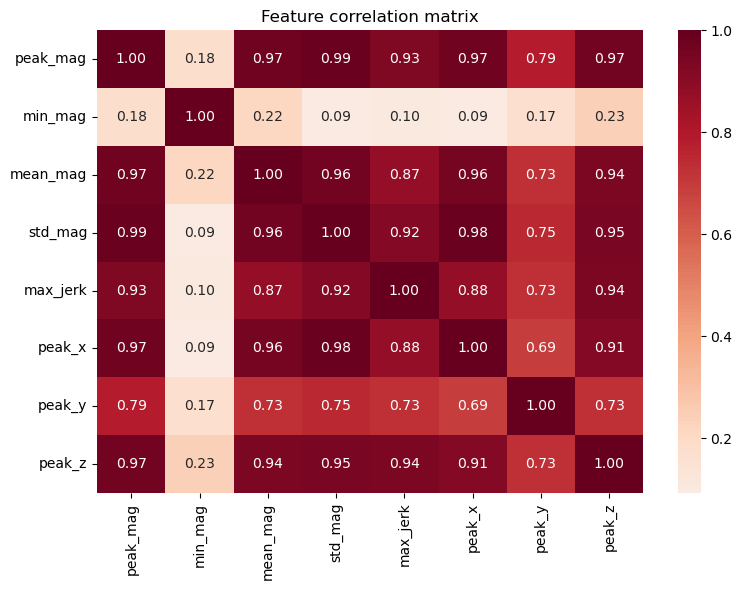

Highly correlated pairs (>0.9) share similar information — models may not need both.


In [6]:
# 2d. Correlation heatmap — are any features redundant?
fig, ax = plt.subplots(figsize=(8, 6))
corr = combined[feat_cols].corr()
sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax)
ax.set_title('Feature correlation matrix')
plt.tight_layout()
plt.show()
print('Highly correlated pairs (>0.9) share similar information — models may not need both.')

---
## 3. Feature engineering

We can create additional features from the raw ones. These **derived features** can sometimes capture relationships that raw values miss.

- **Ratios**: How does the peak compare to the mean? (A sharp spike vs a sustained force)
- **Dynamic range**: peak_mag - min_mag (how much variation in the second)
- **Axis dominance**: Which axis dominates the peak? (Pitches and putts use different swing planes)

In [7]:
def add_engineered_features(df):
    """Add derived features to the dataframe."""
    df = df.copy()
    df['peak_over_mean'] = df['peak_mag'] / df['mean_mag']
    df['std_over_mean'] = df['std_mag'] / df['mean_mag']
    df['jerk_over_mean'] = df['max_jerk'] / df['mean_mag']
    df['dynamic_range'] = df['peak_mag'] - df['min_mag']
    df['z_ratio'] = df['peak_z'] / df['peak_mag']
    df['y_ratio'] = df['peak_y'] / df['peak_mag']
    df['x_ratio'] = df['peak_x'] / df['peak_mag']
    return df

combined = add_engineered_features(combined)
all_feat_cols = feat_cols + ['peak_over_mean', 'std_over_mean', 'jerk_over_mean',
                              'dynamic_range', 'z_ratio', 'y_ratio', 'x_ratio']

print(f'Total features: {len(all_feat_cols)}')
print(f'Raw: {feat_cols}')
print(f'Engineered: {[f for f in all_feat_cols if f not in feat_cols]}')

Total features: 15
Raw: ['peak_mag', 'min_mag', 'mean_mag', 'std_mag', 'max_jerk', 'peak_x', 'peak_y', 'peak_z']
Engineered: ['peak_over_mean', 'std_over_mean', 'jerk_over_mean', 'dynamic_range', 'z_ratio', 'y_ratio', 'x_ratio']


---
## 4. Train-test split strategy

With only ~94 samples across 2 rounds, a single 70/30 split would be unreliable — the test set would only have ~28 samples. Instead we use:

### Stratified K-Fold Cross-Validation
- Split the data into **K folds** (we'll use K=5)
- Train on K-1 folds, test on the held-out fold
- Repeat K times so every sample gets tested exactly once
- **Stratified** means each fold has the same proportion of pitch/chip/putt as the full dataset
- Report the **mean accuracy ± standard deviation** across folds

This gives us a more robust accuracy estimate than a single split.

In [8]:
X = combined[all_feat_cols].values
y = combined['label'].values

# Encode labels: chip=0, pitch=1, putt=2
le = LabelEncoder()
y_encoded = le.fit_transform(y)
print(f'Classes: {list(le.classes_)}')
print(f'Samples per class: {dict(zip(le.classes_, np.bincount(y_encoded)))}')
print(f'Total: {len(X)} samples, {X.shape[1]} features')
print(f'\nClass imbalance: putts ({(y=="putt").sum()}) >> chips ({(y=="chip").sum()})')
print('This imbalance is realistic — in pitch & putt you take more putts than chips.')

Classes: ['chip', 'pitch', 'putt']
Samples per class: {'chip': np.int64(11), 'pitch': np.int64(36), 'putt': np.int64(47)}
Total: 94 samples, 15 features

Class imbalance: putts (47) >> chips (11)
This imbalance is realistic — in pitch & putt you take more putts than chips.


---
## 5. Model comparison

We'll train 5 different algorithms and compare them. Each has different strengths:

| Algorithm | How it works | Strengths | Weaknesses |
|-----------|-------------|-----------|------------|
| **Random Forest** | Builds many decision trees, each on a random subset of features, and votes | Handles non-linear boundaries, resistant to overfitting, gives feature importance | Can struggle with very small classes |
| **Gradient Boosting** | Builds trees sequentially, each correcting the mistakes of the previous one | Often the most accurate, handles imbalance well | Slower to train, can overfit small datasets |
| **Logistic Regression** | Draws linear boundaries between classes in feature space | Fast, interpretable, works well when classes are linearly separable | Fails when boundaries are non-linear |
| **K-Nearest Neighbours (KNN)** | Classifies a sample by looking at what its K closest neighbours are | Simple, no training phase, works with any boundary shape | Sensitive to feature scale and irrelevant features |
| **Support Vector Machine (SVM)** | Finds the boundary that maximises the margin between classes | Works well in high dimensions, effective with small datasets | Less interpretable, needs feature scaling |

In [9]:
# Define models — each wrapped in a Pipeline with StandardScaler
# StandardScaler normalises features to mean=0, std=1. This is important for
# KNN and SVM which are sensitive to feature scale. It doesn't hurt tree-based models.

models = {
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', RandomForestClassifier(n_estimators=100, random_state=42))
    ]),
    'Gradient Boosting': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', GradientBoostingClassifier(n_estimators=100, random_state=42))
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', LogisticRegression(max_iter=1000, random_state=42, multi_class='multinomial'))
    ]),
    'KNN (k=5)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', KNeighborsClassifier(n_neighbors=5))
    ]),
    'SVM (RBF kernel)': Pipeline([
        ('scaler', StandardScaler()),
        ('clf', SVC(kernel='rbf', random_state=42))
    ]),
}

# Cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print(f'{"Model":<25} {"Accuracy":>10} {"Std":>8}')
print('-' * 45)
results = {}
for name, model in models.items():
    scores = cross_val_score(model, X, y_encoded, cv=cv, scoring='accuracy')
    results[name] = scores
    print(f'{name:<25} {scores.mean():>9.1%} {scores.std():>7.1%}')

Model                       Accuracy      Std
---------------------------------------------


Random Forest                 83.0%    3.9%


Gradient Boosting             83.0%    6.1%
Logistic Regression           86.1%    2.7%
KNN (k=5)                     87.2%    2.8%
SVM (RBF kernel)              86.1%    2.7%


/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' 

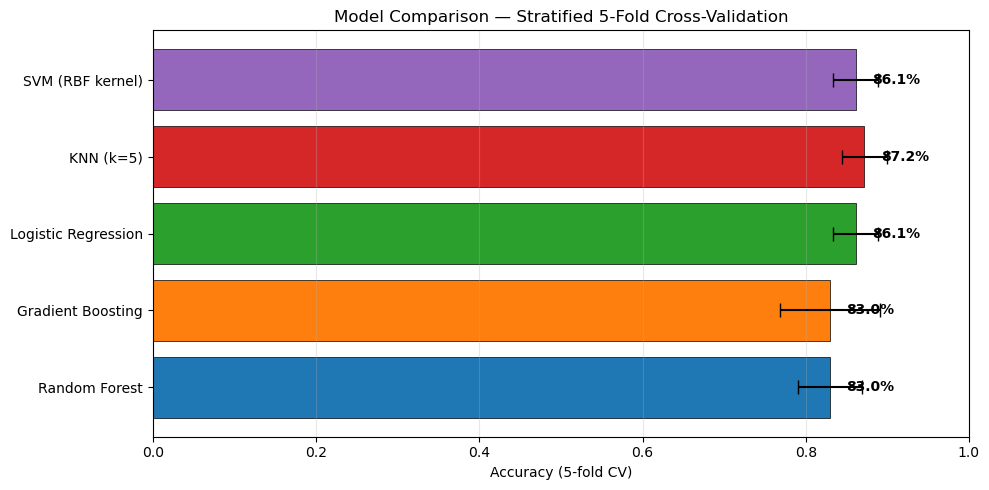

In [10]:
# Visualise model comparison
fig, ax = plt.subplots(figsize=(10, 5))
names = list(results.keys())
means = [results[n].mean() for n in names]
stds = [results[n].std() for n in names]

bars = ax.barh(names, means, xerr=stds, capsize=5, color=['C0','C1','C2','C3','C4'],
               edgecolor='black', linewidth=0.5)
ax.set_xlabel('Accuracy (5-fold CV)')
ax.set_title('Model Comparison — Stratified 5-Fold Cross-Validation')
ax.set_xlim(0, 1)
for bar, m in zip(bars, means):
    ax.text(m + 0.02, bar.get_y() + bar.get_height()/2, f'{m:.1%}',
            va='center', fontsize=10, fontweight='bold')
ax.grid(alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

---
## 6. Detailed evaluation of the best model

Now let's look deeper at the best-performing model. We'll use **cross-validated predictions** (predictions made when each sample was in the held-out fold) to build a confusion matrix and classification report.

In [11]:
# Pick the best model
best_name = max(results, key=lambda k: results[k].mean())
best_model = models[best_name]
print(f'Best model: {best_name} ({results[best_name].mean():.1%} accuracy)\n')

# Get cross-validated predictions (each sample predicted when it was in the test fold)
y_pred = cross_val_predict(best_model, X, y_encoded, cv=cv)

# Classification report
print('Classification Report (cross-validated):')
print('=' * 55)
print(classification_report(y_encoded, y_pred, target_names=le.classes_))

Best model: KNN (k=5) (87.2% accuracy)

Classification Report (cross-validated):
              precision    recall  f1-score   support

        chip       0.00      0.00      0.00        11
       pitch       1.00      0.97      0.99        36
        putt       0.80      1.00      0.89        47

    accuracy                           0.87        94
   macro avg       0.60      0.66      0.62        94
weighted avg       0.78      0.87      0.82        94



/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


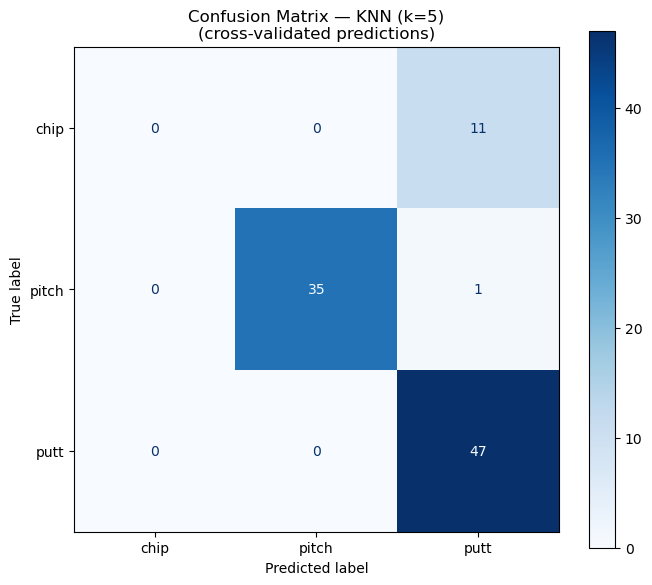


How to read this matrix:
- Rows = actual class, Columns = predicted class
- Diagonal = correct predictions (higher is better)
- Off-diagonal = mistakes (which classes get confused with each other?)


In [12]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(y_encoded, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
disp.plot(ax=ax, cmap='Blues', values_format='d')
ax.set_title(f'Confusion Matrix — {best_name}\n(cross-validated predictions)')
plt.tight_layout()
plt.show()

print('\nHow to read this matrix:')
print('- Rows = actual class, Columns = predicted class')
print('- Diagonal = correct predictions (higher is better)')
print('- Off-diagonal = mistakes (which classes get confused with each other?)')

---
## 7. Feature importance

Which features matter most for classification? Tree-based models (Random Forest, Gradient Boosting) can tell us directly — they measure how much each feature contributes to correct splits.

This is useful for:
- Understanding *why* the model makes its decisions
- Potentially reducing the feature set (fewer features = simpler watch app)
- Knowing what to focus on if we need to improve accuracy

In [13]:
# Train the best model on all data to get feature importances
best_model.fit(X, y_encoded)
clf = best_model.named_steps['clf']

if hasattr(clf, 'feature_importances_'):
    importances = clf.feature_importances_
    sorted_idx = np.argsort(importances)[::-1]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([all_feat_cols[i] for i in sorted_idx],
            importances[sorted_idx], color='C0', edgecolor='black', linewidth=0.5)
    ax.set_xlabel('Feature Importance')
    ax.set_title(f'Feature Importance — {best_name}')
    ax.grid(alpha=0.3, axis='x')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    print('Top 5 features:')
    for i in sorted_idx[:5]:
        print(f'  {all_feat_cols[i]:>20}: {importances[i]:.3f}')
else:
    print(f'{best_name} does not provide feature importances directly.')
    print('Try using Random Forest or Gradient Boosting for interpretability.')

KNN (k=5) does not provide feature importances directly.
Try using Random Forest or Gradient Boosting for interpretability.


---
## 8. The hard problem: Chip vs Putt

From the EDA we know pitch is easy to classify (massive magnitude spike). The real challenge is **chip vs putt** — they have similar magnitude profiles because both are short, controlled swings.

Let's zoom in on just the chip and putt samples to understand where the model struggles.

Chip: 11, Putt: 47


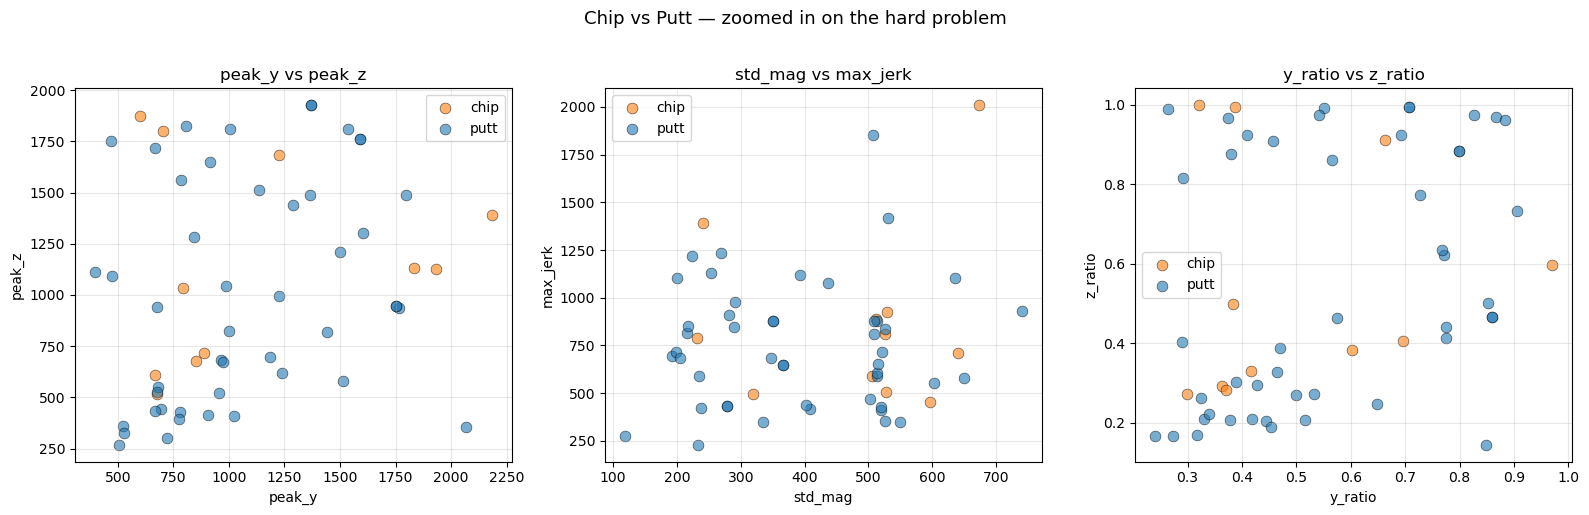

In [14]:
# Filter to chip + putt only
cp = combined[combined['label'].isin(['chip', 'putt'])].copy()
print(f'Chip: {(cp["label"]=="chip").sum()}, Putt: {(cp["label"]=="putt").sum()}')

# Scatter plots of the best separating features for chip vs putt
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

pairs = [('peak_y', 'peak_z'), ('std_mag', 'max_jerk'), ('y_ratio', 'z_ratio')]
for ax, (f1, f2) in zip(axes, pairs):
    for label, c in [('chip', 'C1'), ('putt', 'C0')]:
        sub = cp[cp['label'] == label]
        ax.scatter(sub[f1], sub[f2], label=label, color=c,
                   alpha=0.6, edgecolors='black', linewidth=0.5, s=60)
    ax.set_xlabel(f1)
    ax.set_ylabel(f2)
    ax.legend()
    ax.grid(alpha=0.3)
    ax.set_title(f'{f1} vs {f2}')

plt.suptitle('Chip vs Putt — zoomed in on the hard problem', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

In [15]:
# Binary classifier: chip vs putt only
X_cp = cp[all_feat_cols].values
y_cp = (cp['label'] == 'chip').astype(int).values  # 1=chip, 0=putt

print('Chip vs Putt binary classification (5-fold CV):')
print(f'{"Model":<25} {"Accuracy":>10}')
print('-' * 37)
for name, model in models.items():
    scores = cross_val_score(model, X_cp, y_cp, cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42))
    print(f'{name:<25} {scores.mean():>9.1%}')

print(f'\nBaseline (always predict putt): {(y_cp==0).mean():.1%}')
print('A model must beat this baseline to be useful.')

Chip vs Putt binary classification (5-fold CV):
Model                       Accuracy
-------------------------------------


Random Forest                 79.1%


Gradient Boosting             75.5%
Logistic Regression           79.1%
KNN (k=5)                     79.2%
SVM (RBF kernel)              81.1%

Baseline (always predict putt): 81.0%
A model must beat this baseline to be useful.


/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models (as if multi_class='ovr' were set). Leave it to its default value to avoid this warning.
  warnings.warn(
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1237: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, binary problems will be fit as proper binary  logistic regression models

---
## 9. Cross-round generalisation

A critical test: does a model trained on **one round** generalise to **another round**? If not, the model is just memorising session-specific patterns. We train on R1, test on R3, and vice versa.

In [16]:
# Train on R1, test on R3
r1_data = combined[combined['round'] == 'R1']
r3_data = combined[combined['round'] == 'R3']

X_r1 = r1_data[all_feat_cols].values
y_r1 = le.transform(r1_data['label'].values)
X_r3 = r3_data[all_feat_cols].values
y_r3 = le.transform(r3_data['label'].values)

print('Cross-round generalisation test:')
print(f'{"Model":<25} {"Train R1→Test R3":>18} {"Train R3→Test R1":>18}')
print('-' * 63)
for name, model in models.items():
    # R1 → R3
    model.fit(X_r1, y_r1)
    acc_13 = model.score(X_r3, y_r3)
    
    # R3 → R1
    model.fit(X_r3, y_r3)
    acc_31 = model.score(X_r1, y_r1)
    
    print(f'{name:<25} {acc_13:>17.1%} {acc_31:>17.1%}')

print(f'\nIf these numbers are close to the CV accuracy, the model generalises well.')
print(f'If they drop sharply, the model is overfitting to session-specific patterns.')

Cross-round generalisation test:
Model                       Train R1→Test R3   Train R3→Test R1
---------------------------------------------------------------
Random Forest                         66.7%             72.5%


Gradient Boosting                     50.0%             70.0%
Logistic Regression                   51.9%             80.0%
KNN (k=5)                             87.0%             82.5%
SVM (RBF kernel)                      61.1%             82.5%

If these numbers are close to the CV accuracy, the model generalises well.
If they drop sharply, the model is overfitting to session-specific patterns.


/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/home/g16/anaconda3/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


---
## 10. Summary & next steps

### What we learned
- **Pitch detection is solved** — massive accelerometer signature, trivially separable from chip/putt
- **Chip vs putt is the hard problem** — similar magnitude, similar jerk, similar wrist motion
- **Bare wrist is required** — a sleeve dampens the signal by 4-8x and collapses all classes together
- **Shot markers need window correction** — button press lands 1-4s after the actual impact

### Next steps
1. **GPS course mapping** — if we know the green boundaries, any shot on the green = putt, eliminating the hardest classification problem entirely
2. **More data** — especially chips (currently only 11 samples across 2 rounds) and varied courses
3. **Multi-second features** — look at the pattern over 3-5 seconds around each shot, not just the peak second
4. **False positive rejection** — train a binary "shot vs not-a-shot" detector for the in-the-wild use case
5. **On-watch inference** — once the model is good enough, port it to Monkey C for live classification